# Bosonic Binary Solver: a photonic sampler as a proposal distribution

This notebook is a minimal, self-contained walk through the algorithm of
[arXiv:2510.08274](https://arxiv.org/abs/2510.08274), *A Binary Optimisation
Algorithm for Near-Term Photonic Quantum Processors* (Makarovskiy et al.).

The idea is compact. A train of $m$ optical pulses carrying $|1,0,1,0,\dots\rangle$
passes through fibre delay lines; threshold detectors report which time bins hold at
least one photon, giving one bit string per shot. A trainable classical layer then
flips bit $i$ independently with probability $p_i$. The result is a candidate
solution to a binary optimisation problem, and training minimises $\mathbb{E}[C(X)]$
over both the beamsplitter angles and the flip probabilities.

Two things make the model unusually easy to instrument:

* **the circuit takes no data input** — the only thing the quantum device supplies
  is a distribution over bit strings;
* **the classical post-processing is one independent bit-flip layer**, so the
  distribution over candidates is a closed-form transform of the click distribution.

At small $m$ we can therefore skip sampling entirely: MerLin gives the exact click
distribution and PyTorch differentiates straight through it. That is what this
notebook does. The paper's own shot-based estimator, the classical baselines, and
the source-swap controls live in the full reproduction package, linked at the end.

In [ ]:
%pip install -q merlinquantum

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import perceval as pcvl
import torch
from merlin import ComputationSpace, MeasurementStrategy, QuantumLayer

torch.manual_seed(0)

M = 12                 # binary variables = time bins = optical modes
DELAYS = (1, 3)        # fibre delay-line lengths (the paper uses 1, 3, 9 at larger m)

## 1. The problem

A 0/1 knapsack with $m$ items: pick a subset maximising total value without exceeding
the capacity. The paper minimises a cost, so we take $C(x) = -\text{value}(x)$ for
feasible packings and $C(x) = 0$ for infeasible ones — every value is positive, so an
overweight packing is worse than any feasible one.

The paper does not publish its instance generator; this one draws values and weights
uniformly from $\{1,\dots,20\}$ with capacity at half the total weight, which is the
assumption the reproduction package documents.

At $m = 12$ the whole solution space is 4096 strings, so we can enumerate it and know
the exact optimum to compare against.

In [2]:
rng = np.random.default_rng(7)
values = rng.integers(1, 21, size=M)
weights = rng.integers(1, 21, size=M)
capacity = int(0.5 * weights.sum())

all_bits = np.array(list(itertools.product([0, 1], repeat=M)), dtype=np.int8)
packed_value = all_bits @ values
feasible = (all_bits @ weights) <= capacity
costs = np.where(feasible, -packed_value, 0.0)

optimum = costs.min()
print(f"values   {values}")
print(f"weights  {weights}   capacity {capacity}")
print(f"{len(all_bits)} candidate strings, {feasible.sum()} feasible")
print(f"exact optimum: value {-optimum} (cost {optimum})")

costs_t = torch.tensor(costs, dtype=torch.float64)

values   [19 13 14 18 12 16 17  5  2  7  6 18]
weights  [19  1 10 17  3 16  3 10 17  7  7  6]   capacity 58
4096 candidate strings, 2072 feasible
exact optimum: value 109.0 (cost -109.0)


## 2. The circuit

One beamsplitter per pair of time bins $(t, t+\ell)$, for each delay $\ell$. This is
the topology the paper's own parameter count implies: $\sum_\ell (m - \ell)$ trainable
beamsplitters.

Two conventions matter here and both are easy to get silently wrong:

* `pcvl.BS.Ry` is the **real** rotation. The default `pcvl.BS.Rx` carries factors of
  $i$ and would change every interference term without raising anything.
* delays longer than 1 act on **non-adjacent** modes, so the pair is brought together
  by a permutation, mixed, and sent back.

In [3]:
def build_circuit(m, delays):
    '''Unrolled time-bin interferometer: one beamsplitter per (t, t + delay) pair.'''
    circuit = pcvl.Circuit(m)
    names = []
    for delay in delays:
        for t in range(m - delay):
            name = f"theta_{delay}_{t}"
            names.append(name)
            block = pcvl.BS.Ry(theta=pcvl.P(name))
            if delay == 1:
                circuit.add(t, block)
            else:
                width = delay + 1
                forward = [0] + list(range(2, width)) + [1]
                inverse = [0] * width
                for source, target in enumerate(forward):
                    inverse[target] = source
                circuit.add(t, pcvl.PERM(forward))
                circuit.add(t, block)
                circuit.add(t, pcvl.PERM(inverse))
    return circuit, names


circuit, angle_names = build_circuit(M, DELAYS)
print(f"{len(angle_names)} trainable beamsplitters on {M} modes")

20 trainable beamsplitters on 12 modes


## 3. The quantum layer

`QuantumLayer` with `MeasurementStrategy.probs(ComputationSpace.FOCK)` returns the
exact probability of every Fock outcome — no shots, and differentiable.

The detectors are **threshold** detectors: a mode clicks when it holds at least one
photon, so several Fock outcomes map to the same click pattern. We build that
many-to-one map once and sum probabilities into it, giving the exact distribution over
the $2^m$ click patterns.

In [4]:
layer = QuantumLayer(
    circuit=circuit,
    input_state=[1, 0] * (M // 2),          # |1,0,1,0,...>: m/2 photons in m modes
    trainable_parameters=["theta"],
    measurement_strategy=MeasurementStrategy.probs(ComputationSpace.FOCK),
    dtype=torch.float64,
)

fock_keys = layer.computation_process.simulation_graph.final_keys
place_value = (1 << np.arange(M - 1, -1, -1)).astype(np.int64)
click_index = torch.tensor(
    [int(((np.asarray(key)[:M] > 0) * place_value).sum()) for key in fock_keys],
    dtype=torch.long,
)


def click_distribution():
    '''Exact probability of each of the 2^m threshold-detection patterns.'''
    fock_probabilities = layer().reshape(-1)
    out = torch.zeros(2**M, dtype=fock_probabilities.dtype)
    return out.index_add(0, click_index, fock_probabilities)


clicks = click_distribution()
print(f"{len(fock_keys)} Fock outcomes -> {len(clicks)} click patterns")
print(f"total probability {clicks.sum():.12f}")
clicks_per_mode = float((clicks.detach() * torch.tensor(all_bits.sum(1), dtype=torch.float64)).sum()) / M
print(f"mean clicks per mode {clicks_per_mode:.3f}")

12376 Fock outcomes -> 4096 click patterns
total probability 1.000000000000
mean clicks per mode 0.402


## 4. The trainable bit-flip layer

Each bit is flipped independently with probability $p_i = \sigma(\alpha_i)$. Because
the flips are independent, the distribution over candidates is the click distribution
pushed through one two-point transform per bit — $O(m\,2^m)$ work, and differentiable,
so no sampling is needed at this size:

$$P(X = x) \;=\; \sum_c P(C = c) \prod_i p_i^{[x_i \ne c_i]} (1 - p_i)^{[x_i = c_i]}.$$

In [5]:
def apply_flips(distribution, flip_probabilities):
    '''Push a distribution over bit strings through an independent bit-flip layer.'''
    tensor = distribution.reshape([2] * M)
    for axis, p in enumerate(flip_probabilities):
        tensor = (1 - p) * tensor + p * tensor.flip(axis)
    return tensor.reshape(-1)


alpha = torch.zeros(M, dtype=torch.float64, requires_grad=True)   # p_i = 0.5 at init
candidates = apply_flips(clicks, torch.sigmoid(alpha))
print(f"expected cost before training: {float((candidates * costs_t).sum()):.3f}")
print(f"exact optimum:                 {optimum:.3f}")

expected cost before training: -29.806
exact optimum:                 -109.000


/tmp/ipykernel_1124/2722564530.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  print(f"expected cost before training: {float((candidates * costs_t).sum()):.3f}")


## 5. Training

Plain SGD on both parameter groups, at the paper's learning rates (0.01 for the
angles, 0.05 for the flip logits). The objective is the exact $\mathbb{E}[C(X)]$, so
each step is one deterministic gradient rather than the paper's parameter-shift
estimate over shots.

Alongside the expectation we track the best candidate actually seen — 50 strings drawn
from the current distribution per update, which is the paper's shot count and the
quantity its Appendix B budget counts.

In [6]:
UPDATES, SHOTS = 200, 50

optimiser = torch.optim.SGD(
    [
        {"params": layer.parameters(), "lr": 0.01},
        {"params": [alpha], "lr": 0.05},
    ]
)

generator = torch.Generator().manual_seed(0)
history, best_seen, best_cost = [], [], 0.0

for update in range(UPDATES):
    candidates = apply_flips(click_distribution(), torch.sigmoid(alpha))
    expected_cost = (candidates * costs_t).sum()

    optimiser.zero_grad()
    expected_cost.backward()
    optimiser.step()

    drawn = torch.multinomial(candidates.detach(), SHOTS, replacement=True, generator=generator)
    best_cost = min(best_cost, float(costs_t[drawn].min()))

    history.append(float(expected_cost))
    best_seen.append(best_cost)

print(f"expected cost {history[0]:.3f} -> {history[-1]:.3f}")
print(f"best candidate drawn: {best_seen[-1]:.0f}   exact optimum: {optimum:.0f}")
print(f"optimum found: {best_seen[-1] == optimum}")
print(f"candidates drawn: {UPDATES * SHOTS}; whole solution space: {2**M}")
print("At m = 12 the shot budget already exceeds the space, so this size demonstrates the")
print("mechanism rather than a search advantage — the package reports sizes where it does not.")

expected cost -29.806 -> -90.965
best candidate drawn: -109   exact optimum: -109
optimum found: True
candidates drawn: 10000; whole solution space: 4096
At m = 12 the shot budget already exceeds the space, so this size demonstrates the
mechanism rather than a search advantage — the package reports sizes where it does not.


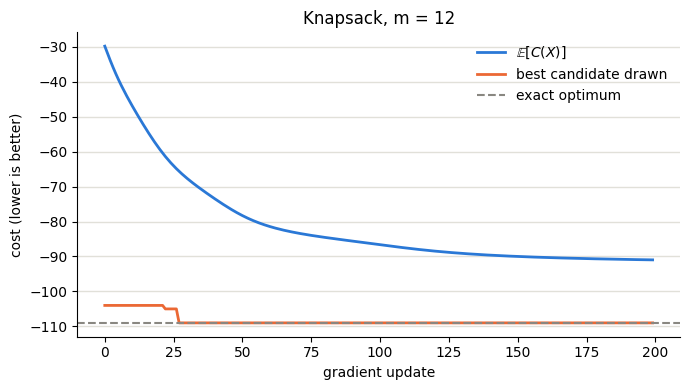

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history, color="#2a78d6", linewidth=2, label=r"$\mathbb{E}[C(X)]$")
ax.plot(best_seen, color="#eb6834", linewidth=2, label="best candidate drawn")
ax.axhline(optimum, color="#898781", linewidth=1.5, linestyle="--", label="exact optimum")
ax.set_xlabel("gradient update")
ax.set_ylabel("cost (lower is better)")
ax.set_title(f"Knapsack, m = {M}")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
fig.tight_layout()

## 6. What the trained parameters look like

The interferometer starts at random angles and the flip layer starts at $p_i = 0.5$,
which is a uniform distribution over candidates. After training, the click marginals
and the flip probabilities together concentrate the candidate distribution.

most likely candidate: 011110100011
  its cost -98, optimum -109
  probability mass on it: 0.281


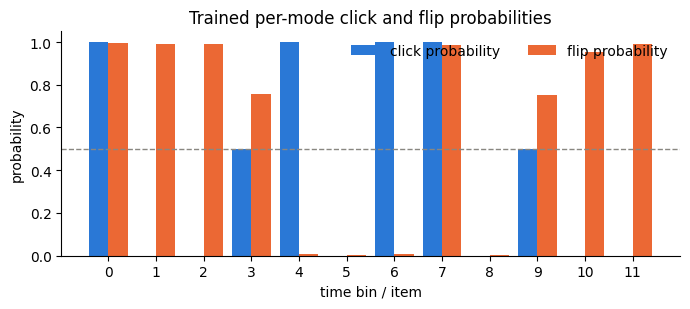

In [8]:
with torch.no_grad():
    final_clicks = click_distribution()
    bits_t = torch.tensor(all_bits, dtype=torch.float64)
    click_marginals = (final_clicks[:, None] * bits_t).sum(0)
    flip_probabilities = torch.sigmoid(alpha)
    final_candidates = apply_flips(final_clicks, flip_probabilities)

best_string = all_bits[int(torch.argmax(final_candidates))]
print(f"most likely candidate: {''.join(map(str, best_string))}")
print(f"  its cost {costs[int(torch.argmax(final_candidates))]:.0f}, optimum {optimum:.0f}")
print(f"  probability mass on it: {float(final_candidates.max()):.3f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
positions = np.arange(M)
ax.bar(positions - 0.2, click_marginals.numpy(), width=0.4, color="#2a78d6", label="click probability")
ax.bar(positions + 0.2, flip_probabilities.numpy(), width=0.4, color="#eb6834", label="flip probability")
ax.axhline(0.5, color="#898781", linewidth=1, linestyle="--")
ax.set_xlabel("time bin / item")
ax.set_ylabel("probability")
ax.set_xticks(positions)
ax.set_title("Trained per-mode click and flip probabilities")
ax.legend(frameon=False, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

## Where to go next

This notebook stays at $m = 12$, where the whole solution space fits in memory and the
expectation is exact. The reproduction package scales the same physics up and adds the
parts that need sampling:

* the paper's shot-based path with the photonic parameter-shift rule, reproducing
  Table I at $m = 20, 25, 30$ and TSP at $m = 29$;
* classical baselines — simulated annealing, hill climbing and uniform random search —
  at the solver's own Appendix B candidate budget;
* a control that holds the circuit, the trained angles, the flip layer and the budget
  fixed and varies only the click source (boson, marginal-preserving shuffle,
  distinguishable photons, independent Bernoulli clicks at several rates);
* a batched GPU path that carries the same comparison out to $m = 60$.

Package and results:
[reproduced_papers/papers/bosonic_binary_solver](https://github.com/merlinquantum/reproduced_papers/tree/main/papers/bosonic_binary_solver).